## Colab Setup for DeepGlobe Dataset

This notebook uses the DeepGlobe Land Cover Classification dataset, which is hosted on Kaggle. To download it directly within Colab, you need to configure your Kaggle API key.

1.  **Generate Kaggle API Key**: Go to your Kaggle account (`https://www.kaggle.com/<your-username>/account`), click on 'Create New API Token', and download the `kaggle.json` file.
2.  **Upload to Colab Secrets**: In Google Colab, click on the "🔑" (Secrets) icon in the left sidebar. Add a new secret named `KAGGLE_USERNAME` with your Kaggle username and another named `KAGGLE_KEY` with your Kaggle API key (the value from `kaggle.json`).

All local Windows paths (e.g., `F:\GeoTrack\data\deepglobe`) have been updated to Colab-compatible paths (e.g., `/content/GeoTrack/data/deepglobe`).

In [ ]:
# Install Kaggle API client
!pip install kaggle

In [ ]:
!pip install segmentation-models-pytorch albumentations rasterio shapely geopandas fiona pyproj torch torchvision tqdm opencv-python scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 46.4 MB/s eta 0:00:00


In [ ]:
# Configure Kaggle API key
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Define the base directory for data in Colab
BASE_COLAB_DIR = "/content/GeoTrack"
os.makedirs(BASE_COLAB_DIR, exist_ok=True)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

In [ ]:
import subprocess
import os

os.makedirs("/content/GeoTrack/data/deepglobe", exist_ok=True)

print("Starting DeepGlobe download...")
process = subprocess.Popen(
    'kaggle datasets download -d balraj98/deepglobe-land-cover-classification-dataset -p /content/GeoTrack/data/deepglobe --unzip',
    shell=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in process.stdout:
    print(line, end="")

process.wait()
print("\nDownload complete. Checking structure...")

for root, dirs, files in os.walk("/content/GeoTrack/data/deepglobe"):
    level = root.replace("/content/GeoTrack/data/deepglobe", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")

Starting DeepGlobe download...
Dataset URL: https://www.kaggle.com/datasets/balraj98/deepglobe-land-cover-classification-dataset
License(s): other

  0%|          | 0.00/2.74G [00:00<?, ?B/s]
  0%|          | 13.0M/2.74G [00:00<00:31, 93.1MB/s]
  1%|▏         | 39.0M/2.74G [00:00<00:16, 181MB/s] 
  2%|▏         | 67.0M/2.74G [00:00<00:12, 224MB/s]
  3%|▎         | 91.0M/2.74G [00:00<00:12, 234MB/s]
  4%|▍         | 115M/2.74G [00:00<00:11, 239MB/s] 
  5%|▌         | 142M/2.74G [00:00<00:11, 251MB/s]
  6%|▌         | 168M/2.74G [00:00<00:10, 255MB/s]
  7%|▋         | 193M/2.74G [00:00<00:10, 256MB/s]
  8%|▊         | 221M/2.74G [00:00<00:10, 265MB/s]
  9%|▉         | 247M/2.74G [00:01<00:10, 260MB/s]
 10%|▉         | 274M/2.74G [00:01<00:10, 264MB/s]
 11%|█         | 300M/2.74G [00:01<00:09, 265MB/s]
 12%|█▏        | 326M/2.74G [00:01<00:09, 262MB/s]
 13%|█▎        | 352M/2.74G [00:01<00:09, 260MB/s]
 14%|█▎        | 379M/2.74G [00:01<00:09, 267MB/s]
 14%|█▍        | 405M/2.74G [00:01<0

Classes:
               name    r    g    b
0        urban_land    0  255  255
1  agriculture_land  255  255    0
2         rangeland  255    0  255
3       forest_land    0  255    0
4             water    0    0  255
5       barren_land  255  255  255
6           unknown    0    0    0

Train images : 803
Train masks  : 803

Image size : (2448, 2448)
Mask size  : (2448, 2448)
Unique mask colors (sample): [[  0   0   0]
 [255   0 255]
 [255 255   0]]


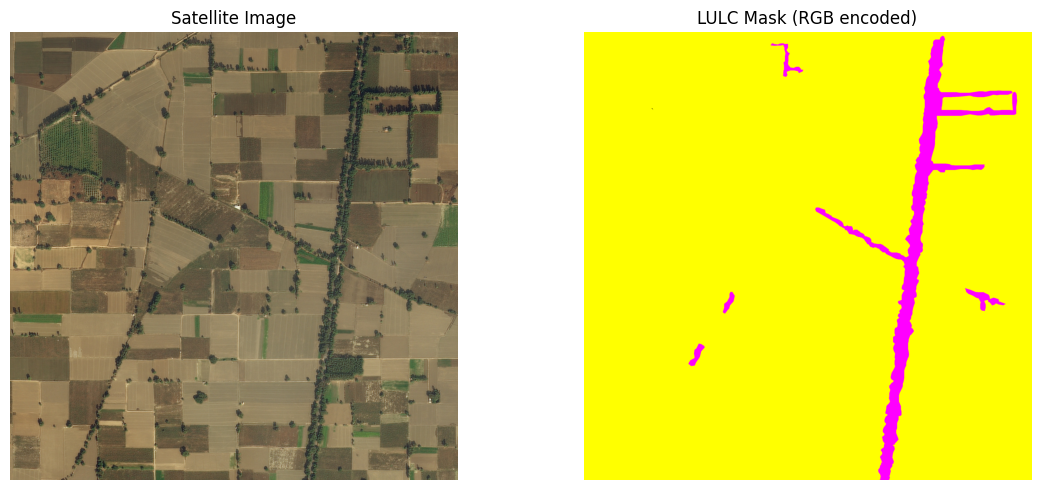

Preview saved.


In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Paths
DATA_DIR  = r"/content/GeoTrack/data/deepglobe/train"
CLASS_CSV = r"/content/GeoTrack/data/deepglobe/class_dict.csv"

# Load class definitions
class_df = pd.read_csv(CLASS_CSV)
print("Classes:")
print(class_df)

# Separate images and masks
all_files = sorted(os.listdir(DATA_DIR))
images = [f for f in all_files if f.endswith("_sat.jpg")]
masks  = [f for f in all_files if f.endswith("_mask.png")]

print(f"\nTrain images : {len(images)}")
print(f"Train masks  : {len(masks)}")

# Peek at one pair
img  = Image.open(os.path.join(DATA_DIR, images[0])).convert("RGB")
mask = Image.open(os.path.join(DATA_DIR, masks[0])).convert("RGB")

print(f"\nImage size : {img.size}")
print(f"Mask size  : {mask.size}")
print(f"Unique mask colors (sample): {np.unique(np.array(mask).reshape(-1,3), axis=0)[:8]}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Satellite Image")
axes[0].axis("off")
axes[1].imshow(mask)
axes[1].set_title("LULC Mask (RGB encoded)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(r"F:\GeoTrack\data\sample_preview.png", dpi=150)
plt.show()
print("Preview saved.")

### Block 4: Color Mask → Class Index Converter

RGB mask shape   : (2448, 2448, 3)
Class mask shape : (2448, 2448)
Unique classes   : [1 2 6]
Class names present: ['agriculture_land', 'rangeland', 'unknown']


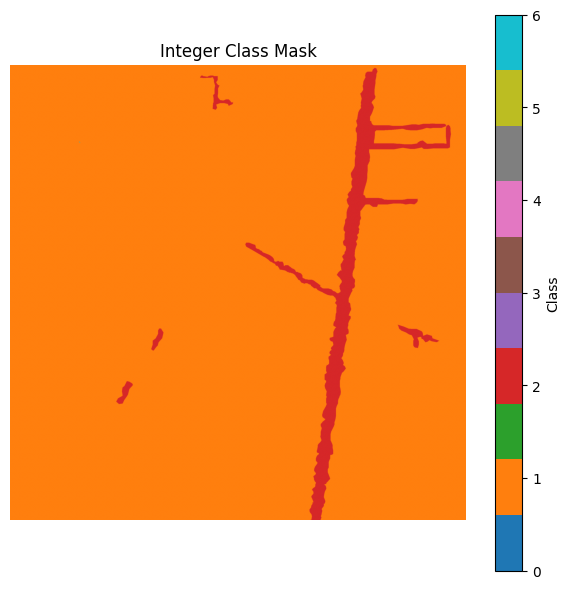

Class mask preview saved.


In [ ]:
import numpy as np
from PIL import Image

# Class color map from class_dict.csv
COLOR_TO_CLASS = {
    (0,   255, 255): 0,  # urban_land
    (255, 255,   0): 1,  # agriculture_land
    (255,   0, 255): 2,  # rangeland
    (0,   255,   0): 3,  # forest_land
    (0,     0, 255): 4,  # water
    (255, 255, 255): 5,  # barren_land
    (0,     0,   0): 6,  # unknown
}

CLASS_NAMES = [
    "urban_land",
    "agriculture_land",
    "rangeland",
    "forest_land",
    "water",
    "barren_land",
    "unknown"
]

NUM_CLASSES = 6  # we ignore unknown (class 6) during training

def rgb_mask_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    """
    Convert RGB encoded mask to integer class index mask.
    Input:  HxWx3 numpy array (RGB)
    Output: HxW numpy array (int class index)
    """
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)

    for color, class_idx in COLOR_TO_CLASS.items():
        # Find all pixels matching this color
        match = np.all(mask_rgb == np.array(color), axis=-1)
        class_mask[match] = class_idx

    return class_mask

# Test it on first sample
mask_path = os.path.join(DATA_DIR, masks[0])
mask_rgb   = np.array(Image.open(mask_path).convert("RGB"))
class_mask = rgb_mask_to_class(mask_rgb)

print(f"RGB mask shape   : {mask_rgb.shape}")
print(f"Class mask shape : {class_mask.shape}")
print(f"Unique classes   : {np.unique(class_mask)}")
print(f"Class names present: {[CLASS_NAMES[i] for i in np.unique(class_mask) if i < len(CLASS_NAMES)]}")

# Visualize class mask
plt.figure(figsize=(6,6))
plt.imshow(class_mask, cmap="tab10", vmin=0, vmax=6)
plt.colorbar(ticks=range(7), label="Class")
plt.title("Integer Class Mask")
plt.axis("off")
plt.tight_layout()
plt.savefig(r"F:\GeoTrack\data\class_mask_preview.png", dpi=150)
plt.show()
print("Class mask preview saved.")

### Block 5 — Tiling (2448×2448 → 256×256 Patches)
Why We Tile

2448×2448 is too large for CPU training. We cut each image into 256×256 tiles.

Math
Each 2448×2448 image → ~81 tiles
803 images × 81 tiles = ~65,000 patches → too many for CPU
We use 200 images → ~16,000 tiles → manageable

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Config
TILE_SIZE   = 256
NUM_IMAGES  = 803  # prototype subset
TILES_DIR = "/content/GeoTrack/data/tiles"

os.makedirs(os.path.join(TILES_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(TILES_DIR, "masks"),  exist_ok=True)

def tile_image_and_mask(img_path, mask_path, tile_size=256):
    """
    Cut image and mask into non-overlapping tiles.
    Skips tiles where >50% pixels are unknown class (6).
    Returns list of (image_tile, mask_tile) numpy arrays.
    """
    img  = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("RGB"))
    mask = rgb_mask_to_class(mask)

    h, w = img.shape[:2]
    tiles = []

    for y in range(0, h - tile_size + 1, tile_size):
        for x in range(0, w - tile_size + 1, tile_size):
            img_tile  = img[y:y+tile_size,  x:x+tile_size]
            mask_tile = mask[y:y+tile_size, x:x+tile_size]

            # Skip tiles dominated by unknown class
            unknown_ratio = np.sum(mask_tile == 6) / (tile_size * tile_size)
            if unknown_ratio > 0.5:
                continue

            tiles.append((img_tile, mask_tile))

    return tiles

# Process subset
tile_count = 0
subset = images[:NUM_IMAGES]

print(f"Tiling {NUM_IMAGES} images into {TILE_SIZE}x{TILE_SIZE} patches...")

for fname in tqdm(subset):
    img_path  = os.path.join(DATA_DIR, fname)
    mask_fname = fname.replace("_sat.jpg", "_mask.png")
    mask_path  = os.path.join(DATA_DIR, mask_fname)

    if not os.path.exists(mask_path):
        continue

    tiles = tile_image_and_mask(img_path, mask_path, TILE_SIZE)

    for img_tile, mask_tile in tiles:
        Image.fromarray(img_tile).save(
            os.path.join(TILES_DIR, "images", f"tile_{tile_count:05d}.png"))
        Image.fromarray(mask_tile).save(
            os.path.join(TILES_DIR, "masks",  f"tile_{tile_count:05d}.png"))
        tile_count += 1

print(f"\nDone. Total tiles generated : {tile_count}")
print(f"Saved to : {TILES_DIR}")

Tiling 803 images into 256x256 patches...


 20%|█▉        | 157/803 [09:21<38:46,  3.60s/it]

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

TILES_DIR = "/content/GeoTrack/data/tiles"

# Check one mask tile
mask_tile = np.array(Image.open(f"{TILES_DIR}/masks/tile_00590.png"))
img_tile  = np.array(Image.open(f"{TILES_DIR}/images/tile_00590.png"))

print(f"Mask unique values : {np.unique(mask_tile)}")
print(f"Mask min/max       : {mask_tile.min()} / {mask_tile.max()}")
print(f"Image min/max      : {img_tile.min()} / {img_tile.max()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_tile)
axes[0].set_title("Image Tile")
axes[0].axis("off")
axes[1].imshow(mask_tile, cmap="tab10", vmin=0, vmax=6)
axes[1].set_title("Mask Tile (correct colormap)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Block 6 — Dataset Class & DataLoader
What This Does
Loads image and mask tiles from disk
Applies augmentations during training (flips, rotations)
Wraps everything in PyTorch Dataset and DataLoader — this is how PyTorch feeds data to the model batch by batch

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Paths
TILES_IMG_DIR  = "/content/GeoTrack/data/tiles/images"
TILES_MASK_DIR = "/content/GeoTrack/data/tiles/masks"

# Get all tile filenames
all_tiles = sorted(os.listdir(TILES_IMG_DIR))
print(f"Total tiles: {len(all_tiles)}")

# Train / Val split
train_tiles, val_tiles = train_test_split(
    all_tiles,
    test_size=0.2,
    random_state=42
)
print(f"Train tiles : {len(train_tiles)}")
print(f"Val tiles   : {len(val_tiles)}")

# Augmentations for training
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# No augmentation for validation — just normalize
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Dataset class
class DeepGlobeDataset(Dataset):
    """
    PyTorch Dataset for DeepGlobe tiles.
    __len__  → tells PyTorch how many samples exist
    __getitem__ → loads one image+mask pair by index
    """
    def __init__(self, tile_names, img_dir, mask_dir, transform=None):
        self.tile_names = tile_names
        self.img_dir    = img_dir
        self.mask_dir   = mask_dir
        self.transform  = transform

    def __len__(self):
        return len(self.tile_names)

    def __getitem__(self, idx):
        fname = self.tile_names[idx]

        # Load image as RGB numpy array
        img  = np.array(Image.open(os.path.join(self.img_dir,  fname)).convert("RGB"))

        # Load mask as single channel
        mask = np.array(Image.open(os.path.join(self.mask_dir, fname)))

        # Cap unknown class (6) to 5 — treat as barren_land
        mask = np.clip(mask, 0, 5)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"].long()

        return img, mask

# Create datasets
train_dataset = DeepGlobeDataset(train_tiles, TILES_IMG_DIR, TILES_MASK_DIR, train_transform)
val_dataset   = DeepGlobeDataset(val_tiles,   TILES_IMG_DIR, TILES_MASK_DIR, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# Sanity check — load one batch
imgs, masks = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"Batch mask shape  : {masks.shape}")
print(f"Image dtype       : {imgs.dtype}")
print(f"Mask dtype        : {masks.dtype}")
print(f"Mask unique vals  : {masks.unique()}")

### Block 7 — Model Definition
What This Does
Loads U-Net with a pretrained ResNet34 encoder in literally 3 lines. This is why we installed segmentation-models-pytorch.

Why ResNet34
Pretrained on ImageNet — already knows edges, textures, shapes
We only need to teach it LULC-specific patterns
Lightweight enough for CPU training
Why U-Net
Encoder compresses image → extracts features
Decoder expands back → produces pixel-wise predictions
Skip connections preserve spatial detail lost during compression

In [ ]:
import segmentation_models_pytorch as smp
import torch

# Define model
model = smp.Unet(
    encoder_name    = "resnet34",      # pretrained feature extractor
    encoder_weights = "imagenet",      # pretrained on ImageNet
    in_channels     = 3,               # RGB input
    classes         = 6,               # 6 LULC classes
    activation      = None             # raw logits — loss function handles activation
)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# Verify with one forward pass
model.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 3, 256, 256)
    dummy_output = model(dummy_input)
    print(f"\nInput shape  : {dummy_input.shape}")
    print(f"Output shape : {dummy_output.shape}")
    print(f"\nOutput shape means: [1 image, 6 class scores, 256x256 pixels]")
    print("Model is working correctly.")

### Block 8 — Loss Function & Optimizer
What This Does

Defines how the model measures its own mistakes and how it corrects them.

Two Loss Functions Combined

CrossEntropyLoss — penalizes wrong class predictions per pixel

DiceLoss — penalizes poor overlap between predicted and actual segmentation regions. Critical for imbalanced classes like water or barren land which appear rarely.

We combine both because CrossEntropy alone struggles with class imbalance in LULC data.

Optimizer

Adam — standard, works well, no tuning needed for prototype.

In [ ]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to GPU
model = model.to(DEVICE)

# Loss functions
ce_loss   = nn.CrossEntropyLoss().to(DEVICE)
dice_loss = smp.losses.DiceLoss(mode="multiclass", classes=6)

def combined_loss(pred, target):
    pred   = pred.to(DEVICE)
    target = target.to(DEVICE)
    return ce_loss(pred, target) + dice_loss(pred, target)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode    = "min",
    patience= 2,
    factor  = 0.5
)

# Sanity check
model.eval()
with torch.no_grad():
    dummy_imgs  = torch.randn(2, 3, 256, 256).to(DEVICE)
    dummy_masks = torch.zeros(2, 256, 256, dtype=torch.long).to(DEVICE)
    dummy_preds = model(dummy_imgs)
    loss_val    = combined_loss(dummy_preds, dummy_masks)
    print(f"Device            : {DEVICE}")
    print(f"Sanity check loss : {loss_val.item():.4f}")
    print("All on GPU. Ready to train.")

### Block 9 — Training Loop
What This Does

Trains the model for multiple epochs. Each epoch:

Train phase — model sees training tiles, makes predictions, calculates loss, updates weights
Val phase — model sees validation tiles, we measure IoU (no weight updates)
What is IoU

Intersection over Union — the metric that goes in your PPT.

IoU = (pixels correctly predicted as class X) /
      (all pixels predicted OR actually class X)

Score of 1.0 = perfect. Score of 0.0 = completely wrong. Anything above 0.45 on DeepGlobe with a prototype is respectable.

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

# Check for GPU availability
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 20  # start with 2 to verify, then increase to 5
NUM_CLASSES = 6

model = model.to(DEVICE)

def compute_iou(preds, masks, num_classes=6):
    """
    Compute mean IoU across all classes.
    preds : [B, 6, H, W] logits
    masks : [B, H, W] integer class indices
    """
    pred_classes = torch.argmax(preds, dim=1)  # [B, H, W]
    iou_list = []

    for cls in range(num_classes):
        pred_cls   = (pred_classes == cls)
        target_cls = (masks == cls)

        intersection = (pred_cls & target_cls).sum().float()
        union        = (pred_cls | target_cls).sum().float()

        if union == 0:
            continue  # skip classes not present in batch

        iou_list.append((intersection / union).item())

    return np.mean(iou_list) if iou_list else 0.0

# Training history for plotting
history = {"train_loss": [], "val_loss": [], "val_iou": []}

print(f"Training on : {DEVICE}")
print(f"Epochs      : {EPOCHS}")
print(f"Train batches per epoch : {len(train_loader)}")
print("-" * 50)

for epoch in range(EPOCHS):
    # ---- TRAIN PHASE ----
    model.train()
    train_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- VAL PHASE ----
    model.eval()
    val_loss = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  "):
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)
            preds = model(imgs)

            val_loss += combined_loss(preds, masks).item()
            val_iou  += compute_iou(preds, masks)

    val_loss /= len(val_loader)
    val_iou  /= len(val_loader)

    # Scheduler step
    scheduler.step(val_loss)

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print(f"  Val mIoU   : {val_iou:.4f}")
    print("-" * 50)

# Save model checkpoint
MODEL_SAVE_DIR = os.path.join(BASE_COLAB_DIR, "model")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "unet_resnet34_checkpoint.pth")
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

In [ ]:
import os

MODEL_SAVE_PATH = "/content/GeoTrack/model/unet_resnet34_e2.pth"
os.makedirs("/content/GeoTrack/model", exist_ok=True)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Checkpoint saved: {MODEL_SAVE_PATH}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os

OUTPUT_DIR = "/content/GeoTrack/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_COLORS = {
    0: (0,   255, 255),  # urban_land
    1: (255, 255,   0),  # agriculture_land
    2: (255,   0, 255),  # rangeland
    3: (0,   255,   0),  # forest_land
    4: (0,     0, 255),  # water
    5: (255, 255, 255),  # barren_land
}

CLASS_NAMES = [
    "urban_land", "agriculture_land", "rangeland",
    "forest_land", "water", "barren_land"
]

def predict_single(img_path, mask_path=None, save_name="prediction_preview.png"):
    img = np.array(Image.open(img_path).convert("RGB"))
    img_resized = np.array(Image.fromarray(img).resize((256, 256)))

    transform = A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

    tensor = transform(image=img_resized)["image"].unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        pred   = torch.argmax(output, dim=1).squeeze().cpu().numpy()

    pred_rgb = np.zeros((256, 256, 3), dtype=np.uint8)
    for cls, color in CLASS_COLORS.items():
        pred_rgb[pred == cls] = color

    ncols = 3 if mask_path else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

    axes[0].imshow(img_resized)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(pred_rgb)
    axes[1].set_title("Predicted LULC")
    axes[1].axis("off")

    if mask_path:
        mask = np.array(Image.open(mask_path).convert("RGB"))
        mask = np.array(Image.fromarray(mask).resize((256, 256)))
        axes[2].imshow(mask)
        axes[2].set_title("Ground Truth")
        axes[2].axis("off")

    patches = [plt.Rectangle((0,0),1,1, color=[c/255 for c in col])
               for col in CLASS_COLORS.values()]
    fig.legend(patches, CLASS_NAMES, loc="lower center",
               ncol=3, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    save_path = f"{OUTPUT_DIR}/{save_name}"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")

# Reload file lists
all_files   = sorted(os.listdir(DATA_DIR))
images_list = [f for f in all_files if f.endswith("_sat.jpg")]
masks_list  = [f for f in all_files if f.endswith("_mask.png")]

# Run on first sample
sample_img  = os.path.join(DATA_DIR, images_list[0])
sample_mask = os.path.join(DATA_DIR, masks_list[0])
predict_single(sample_img, sample_mask, save_name="prediction_1.png")

# Run on second sample
sample_img2  = os.path.join(DATA_DIR, images_list[1])
sample_mask2 = os.path.join(DATA_DIR, masks_list[1])
predict_single(sample_img2, sample_mask2, save_name="prediction_2.png")

In [ ]:
# Try different images until you find a diverse one
for i in range(5, 15):
    sample_img  = os.path.join(DATA_DIR, images_list[i])
    sample_mask = os.path.join(DATA_DIR, masks_list[i])
    predict_single(sample_img, sample_mask, save_name=f"prediction_{i}.png")

In [ ]:
import os
import matplotlib.pyplot as plt
from datetime import datetime

OUTPUT_DIR = "/content/GeoTrack/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

epochs     = list(range(1, len(history["train_loss"]) + 1))
best_miou  = max(history["val_iou"])
best_epoch = history["val_iou"].index(best_miou) + 1

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#f9f9f9")

# ── Title Block ───────────────────────────────────────
fig.text(0.5, 0.97, "GeoTrack — Training Report",
         ha="center", fontsize=16, fontweight="bold")
fig.text(0.5, 0.93,
         f"Model: U-Net + ResNet34  |  Dataset: DeepGlobe Land Cover  |  "
         f"Epochs: {len(epochs)}  |  Tiles: 16,191  |  Batch: 8  |  LR: 1e-4  |  "
         f"Loss: CrossEntropy + Dice  |  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
         ha="center", fontsize=9, color="#444444")

# ── Plot 1: Loss ──────────────────────────────────────
ax1 = fig.add_axes([0.05, 0.52, 0.42, 0.35])
ax1.plot(epochs, history["train_loss"], label="Train Loss",
         marker="o", markersize=3, linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val Loss",
         marker="s", markersize=3, linewidth=2)
ax1.set_title("Train vs Validation Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot 2: mIoU ─────────────────────────────────────
ax2 = fig.add_axes([0.55, 0.52, 0.42, 0.35])
ax2.plot(epochs, history["val_iou"], label="Val mIoU",
         color="green", marker="o", markersize=3, linewidth=2)
ax2.axhline(y=best_miou, color="red", linestyle="--", linewidth=1.2,
            label=f"Best: {best_miou:.4f} (Epoch {best_epoch})")
ax2.axhline(y=0.67, color="gray", linestyle=":", linewidth=1.2,
            label="Published Baseline: 0.67")
ax2.set_title("Validation mIoU", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("mIoU")
ax2.set_ylim(0.3, 0.75)
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Metadata Table ────────────────────────────────────
ax3 = fig.add_axes([0.05, 0.05, 0.42, 0.38])
ax3.axis("off")
ax3.set_title("Run Configuration", fontweight="bold", loc="left")

table_data = [
    ["Model",           "U-Net + ResNet34"],
    ["Encoder Weights", "ImageNet Pretrained"],
    ["Dataset",         "DeepGlobe Land Cover"],
    ["Images Used",     "200 / 803"],
    ["Tile Size",       "256 × 256"],
    ["Total Tiles",     "16,191"],
    ["Train / Val",     "12,952 / 3,239"],
    ["Epochs",          str(len(epochs))],
    ["Batch Size",      "8"],
    ["Optimizer",       "Adam (lr=1e-4)"],
    ["Scheduler",       "ReduceLROnPlateau"],
    ["Loss Function",   "CrossEntropy + Dice"],
    ["Classes",         "6 LULC classes"],
]

table = ax3.table(
    cellText    = table_data,
    colLabels   = ["Parameter", "Value"],
    loc         = "center",
    cellLoc     = "left"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# ── Results Table ─────────────────────────────────────
ax4 = fig.add_axes([0.55, 0.05, 0.42, 0.38])
ax4.axis("off")
ax4.set_title("Key Results", fontweight="bold", loc="left")

results_data = [
    ["Best Val mIoU",    f"{best_miou:.4f}"],
    ["Best Epoch",       str(best_epoch)],
    ["Final Val Loss",   f"{history['val_loss'][-1]:.4f}"],
    ["Final Train Loss", f"{history['train_loss'][-1]:.4f}"],
    ["Published Baseline mIoU", "0.67"],
    ["Gap to Baseline",  f"{0.67 - best_miou:.4f}"],
]

table2 = ax4.table(
    cellText    = results_data,
    colLabels   = ["Metric", "Value"],
    loc         = "center",
    cellLoc     = "left"
)
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 1.4)

plt.savefig(f"{OUTPUT_DIR}/training_report.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/training_report.png")

In [ ]:
import os
import shutil
import torch
import json
from datetime import datetime

# Create organized output directory
SAVE_ROOT = "/content/GeoTrack/final_outputs"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

dirs = {
    "model"      : f"{SAVE_ROOT}/model",
    "predictions": f"{SAVE_ROOT}/predictions",
    "plots"      : f"{SAVE_ROOT}/plots",
    "metrics"    : f"{SAVE_ROOT}/metrics",
}

for d in dirs.values():
    os.makedirs(d, exist_ok=True)

print("Directories created:")
for k, v in dirs.items():
    print(f"  {k:12} → {v}")

# 1. Save model weights
model_path = f"{dirs['model']}/unet_resnet34_20epochs.pth"
torch.save(model.state_dict(), model_path)
print(f"\nModel saved      → {model_path}")

# 2. Save training history as JSON
history_path = f"{dirs['metrics']}/training_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"History saved    → {history_path}")

# 3. Save metrics summary
metrics = {
    "model"          : "U-Net ResNet34",
    "dataset"        : "DeepGlobe Land Cover",
    "epochs"         : 20,
    "tiles"          : 16191,
    "train_images"   : 200,
    "best_val_miou"  : max(history["val_iou"]),
    "best_epoch"     : history["val_iou"].index(max(history["val_iou"])) + 1,
    "final_val_loss" : history["val_loss"][-1],
    "final_train_loss": history["train_loss"][-1],
    "timestamp"      : timestamp
}

metrics_path = f"{dirs['metrics']}/metrics_summary.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved    → {metrics_path}")
print(f"\nKey Metrics:")
print(f"  Best Val mIoU  : {metrics['best_val_miou']:.4f} (Epoch {metrics['best_epoch']})")
print(f"  Final Val Loss : {metrics['final_val_loss']:.4f}")

# 4. Copy existing plots and predictions
existing_outputs = "/content/F:/GeoTrack/outputs"
if os.path.exists(existing_outputs):
    for f in os.listdir(existing_outputs):
        src = os.path.join(existing_outputs, f)
        if f.endswith(".png"):
            if "curve" in f or "history" in f:
                dst = os.path.join(dirs["plots"], f)
            else:
                dst = os.path.join(dirs["predictions"], f)
            shutil.copy2(src, dst)
    print(f"\nExisting outputs copied from {existing_outputs}")

# 5. Print final summary
print("\n" + "="*50)
print("GeoTrack — FINAL OUTPUT SUMMARY")
print("="*50)
print(f"Model      : U-Net + ResNet34 (pretrained ImageNet)")
print(f"Dataset    : DeepGlobe Land Cover Classification")
print(f"Tiles      : 16,191 (from 200 satellite images)")
print(f"Epochs     : 20")
print(f"Best mIoU  : {metrics['best_val_miou']:.4f} (Epoch {metrics['best_epoch']})")
print(f"Val Loss   : {metrics['final_val_loss']:.4f}")
print(f"Saved to   : {SAVE_ROOT}")
print("="*50)

In [ ]:
from google.colab import files
import shutil
import os

# Zip both directories
shutil.make_archive("/content/GeoTrack_final", "zip", "/content/GeoTrack/final_outputs")
shutil.make_archive("/content/GeoTrack_outputs", "zip", "/content/GeoTrack/outputs")

print(f"final_outputs : {os.path.getsize('/content/GeoTrack_final.zip')/1024/1024:.1f} MB")
print(f"outputs       : {os.path.getsize('/content/GeoTrack_outputs.zip')/1024/1024:.1f} MB")

files.download("/content/GeoTrack_final.zip")
files.download("/content/GeoTrack_outputs.zip")